![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E12 - Patron ReAct paso a paso
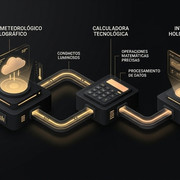

*Figura E12. Trace ReAct paso a paso con herramientas.*

## Escenario

Seguimos con el reporte semanal de ventas.

Ahora vamos a ordenar el comportamiento del agente con el patron **ReAct**:

```text
Pensamiento -> Accion -> Observacion -> Pensamiento -> Accion -> Observacion -> Respuesta final
```

Este notebook combina teoria y practica en cada bloque para que puedas ejecutar y entender al mismo tiempo.


## Mapa visual de ReAct

```text
Consulta del usuario
      |
      v
[Pensamiento] ¿Qué necesito saber?
      |
      v
[Accion] ¿Qué herramienta ejecuto?
      |
      v
[Observacion] ¿Qué devolvió la herramienta?
      |
      v
Decisión: ¿tengo suficiente información?
      |                  |
      | no               | si
      v                  v
otra accion        respuesta final
```

Tabla de conceptos:

| Concepto | Significado | En este notebook |
|---|---|---|
| Pensamiento | Necesidad actual del agente. | "Necesito las filas de ventas". |
| Accion | Herramienta que se ejecuta. | `buscar_datos_ventas()`. |
| Observacion | Resultado de la accion. | Lista de ventas o total. |
| Trace | Registro de pasos. | Lista con pensamiento, accion y observacion. |
| pasos_maximos | Limite de seguridad. | Evita loops infinitos. |


## Bloque 1 - Herramientas locales

Primero definimos las herramientas reales en Python.

Todavia no usamos OpenAI. Esto es importante: las herramientas existen aunque no haya modelo.

```text
buscar_datos_ventas -> devuelve filas
calcular_total -> calcula ingreso
resumir_tendencias -> resume producto destacado
```


In [ ]:
DATOS_VENTAS = [
    {"producto": "Pro", "unidades": 12, "precio_unitario": 30},
    {"producto": "Starter", "unidades": 20, "precio_unitario": 12},
    {"producto": "Enterprise", "unidades": 3, "precio_unitario": 120},
]


def buscar_datos_ventas() -> list[dict]:
    """Herramienta: obtiene filas de ventas semanales."""
    return DATOS_VENTAS


def calcular_total(filas: list[dict]) -> float:
    """Herramienta: calcula el ingreso total semanal."""
    return sum(fila["unidades"] * fila["precio_unitario"] for fila in filas)


def resumir_tendencias(filas: list[dict]) -> str:
    """Herramienta: resume tendencias de ventas."""
    producto_top = max(filas, key=lambda fila: fila["unidades"])
    return f"Producto con mas unidades: {producto_top['producto']} ({producto_top['unidades']} unidades)."


print(f"buscar_datos_ventas() -> {buscar_datos_ventas()}")
print(f"calcular_total(buscar_datos_ventas()) -> {calcular_total(buscar_datos_ventas())}")
print(f"resumir_tendencias(buscar_datos_ventas()) -> {resumir_tendencias(buscar_datos_ventas())}")


## Bloque 2 - Registro de herramientas

Para que un agente pueda ejecutar herramientas de forma ordenada, conviene tener un registro.

```text
nombre de herramienta -> funcion Python real
```

Esto permite que si el modelo pide `calcular_total`, nuestro codigo sepa que funcion ejecutar.


In [ ]:
REGISTRO_HERRAMIENTAS = {
    "buscar_datos_ventas": buscar_datos_ventas,
    "calcular_total": calcular_total,
    "resumir_tendencias": resumir_tendencias,
}


def ejecutar_herramienta(nombre: str, argumentos: dict | None = None):
    """Ejecuta una herramienta local por nombre."""
    argumentos = argumentos or {}
    funcion = REGISTRO_HERRAMIENTAS[nombre]
    return funcion(**argumentos)


print(f"Herramientas disponibles -> {list(REGISTRO_HERRAMIENTAS)}")
print(f"ejecutar_herramienta('buscar_datos_ventas') -> {ejecutar_herramienta('buscar_datos_ventas')}")


## Bloque 3 - ReAct completo y deterministico

Ahora armamos el trace a mano para entender el patron sin depender de OpenAI.

Que mirar al ejecutar:

- cada pensamiento explica que falta;
- cada accion ejecuta una herramienta;
- cada observacion muestra el resultado;
- la respuesta final usa datos observados.


In [ ]:
def ejecutar_reporte_react(pasos_maximos: int = 5) -> str:
    """Loop ReAct deterministico para el reporte de ventas."""
    if pasos_maximos < 3:
        return "pasos_maximos es demasiado bajo para completar el reporte"

    trace = []

    pensamiento = "Necesito las filas de ventas semanales."
    print(f"[Pensamiento] {pensamiento}")
    print("[Accion] buscar_datos_ventas()")
    filas = buscar_datos_ventas()
    print(f"[Observacion] {filas}")
    trace.append({"pensamiento": pensamiento, "accion": "buscar_datos_ventas", "observacion": filas})

    pensamiento = "Necesito calcular el ingreso total."
    print(f"[Pensamiento] {pensamiento}")
    print("[Accion] calcular_total(filas)")
    total = calcular_total(filas)
    print(f"[Observacion] total={total}")
    trace.append({"pensamiento": pensamiento, "accion": "calcular_total", "observacion": total})

    pensamiento = "Necesito un resumen corto de tendencias."
    print(f"[Pensamiento] {pensamiento}")
    print("[Accion] resumir_tendencias(filas)")
    tendencia = resumir_tendencias(filas)
    print(f"[Observacion] {tendencia}")
    trace.append({"pensamiento": pensamiento, "accion": "resumir_tendencias", "observacion": tendencia})

    respuesta_final = f"El ingreso semanal es USD {total}. {tendencia}"
    print(f"[Respuesta final] {respuesta_final}")
    return respuesta_final


ejecutar_reporte_react(pasos_maximos=5)


## Bloque 4 - Completar un trace incompleto

Ahora los pensamientos ya estan escritos.

Tu tarea es conectar cada pensamiento con la herramienta correcta.

```text
Pensamiento escrito -> elegir herramienta -> ejecutar -> imprimir observacion
```


In [ ]:
def ejecutar_trace_incompleto():
    """El alumno completa acciones y observaciones desde los pensamientos."""
    print("[Pensamiento] Necesito las filas de ventas semanales.")
    # TODO 1: llamar buscar_datos_ventas y mostrar la observacion.

    print("[Pensamiento] Necesito calcular el ingreso total.")
    # TODO 2: llamar calcular_total y mostrar la observacion.

    print("[Pensamiento] Necesito un resumen corto de tendencias.")
    # TODO 3: llamar resumir_tendencias y mostrar la observacion.

    # TODO 4: mostrar y devolver la respuesta final.
    pass


ejecutar_trace_incompleto()


## Bloque 5 - Schemas que se mandan a OpenAI

Ahora pasamos del ReAct manual al ReAct asistido por modelo.

De nuevo, separacion clave:

```text
Funcion Python real       Schema para OpenAI
buscar_datos_ventas  ->   nombre + descripcion + parametros
calcular_total       ->   nombre + descripcion + parametros
resumir_tendencias   ->   nombre + descripcion + parametros
```

OpenAI recibe el schema y puede pedir una llamada. Nuestro codigo ejecuta la funcion real.


In [ ]:
def construir_schemas_openai() -> list[dict]:
    """Construye la lista de herramientas que se envia a OpenAI."""
    return [
        {
            "type": "function",
            "function": {
                "name": "buscar_datos_ventas",
                "description": "Obtiene filas de ventas semanales para armar un reporte.",
                "parameters": {"type": "object", "properties": {}},
            },
        },
        {
            "type": "function",
            "function": {
                "name": "calcular_total",
                "description": "Calcula el ingreso total a partir de filas de ventas ya obtenidas.",
                "parameters": {"type": "object", "properties": {}},
            },
        },
        {
            "type": "function",
            "function": {
                "name": "resumir_tendencias",
                "description": "Resume tendencias de ventas a partir de filas ya obtenidas.",
                "parameters": {"type": "object", "properties": {}},
            },
        },
    ]


schemas_openai = construir_schemas_openai()
print("Schemas enviados a OpenAI:")
print(schemas_openai)


## Bloque 6 - Cargar OpenAI API key

Ejecuta esta celda solo si vas a probar la parte con OpenAI real.

La clave no se imprime en pantalla.


In [ ]:
import os
import getpass

api_key = getpass.getpass("Ingresá tu OpenAI API key: ")
os.environ["OPENAI_API_KEY"] = api_key
print("OPENAI_API_KEY cargada en esta sesion.")


## Bloque 7 - Pedir al modelo una decision de herramienta

Esta celda muestra que le mandamos al modelo:

1. mensajes del usuario;
2. schemas de herramientas;
3. instruccion de que puede elegir una herramienta.

Luego imprimimos que decidio.

Si no cargaste API key, no se rompe: solo muestra un mensaje.


In [ ]:
import os
import subprocess
import sys


def obtener_clase_openai():
    """Importa OpenAI. En Colab, intenta instalar el paquete si no existe."""
    try:
        from openai import OpenAI
        return OpenAI
    except ImportError:
        print("No encuentro el paquete openai. Intento instalarlo en esta sesion...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "openai"])
            from openai import OpenAI
            return OpenAI
        except Exception as error:
            print("No pude instalar/importar openai automaticamente.")
            print("Ejecuta en una celda aparte: !pip install -U openai")
            print(f"Error original: {type(error).__name__}: {error}")
            return None


def crear_cliente_openai():
    """Crea el cliente de OpenAI si hay API key disponible."""
    clave_api = os.getenv("OPENAI_API_KEY")
    if not clave_api:
        print("Configura OPENAI_API_KEY para ejecutar la demo real del planificador ReAct con OpenAI.")
        return None

    OpenAI = obtener_clase_openai()
    if OpenAI is None:
        return None

    return OpenAI(api_key=clave_api)


def construir_mensajes_react() -> list[dict]:
    """Construye los mensajes para pedir al modelo que planifique herramientas."""
    return [
        {
            "role": "user",
            "content": "Planifica que herramientas hacen falta para crear un reporte semanal de ventas.",
        }
    ]


def validar_payload_openai(mensajes: list[dict], herramientas: list[dict]) -> None:
    """Valida el payload antes de enviarlo a OpenAI."""
    if not isinstance(mensajes, list) or not mensajes:
        raise ValueError("mensajes debe ser una lista no vacia de diccionarios.")
    if not all(isinstance(mensaje, dict) and "role" in mensaje and "content" in mensaje for mensaje in mensajes):
        raise ValueError("cada mensaje debe tener role y content.")
    if not isinstance(herramientas, list) or not herramientas:
        raise ValueError("herramientas debe ser una lista no vacia de schemas.")
    if not all(herramienta.get("type") == "function" for herramienta in herramientas):
        raise ValueError('cada herramienta debe tener type="function".')


def llamar_openai_con_herramientas(cliente, mensajes: list[dict], herramientas: list[dict]):
    """Envia mensajes + tools a OpenAI y devuelve el mensaje del modelo."""
    validar_payload_openai(mensajes, herramientas)

    payload = {
        "model": "gpt-4o-mini",
        "messages": mensajes,
        "tools": herramientas,
        # No hace falta enviar tool_choice="auto": es el comportamiento por defecto cuando hay tools.
    }

    print("Payload enviado a OpenAI:")
    print(payload)

    try:
        respuesta = cliente.chat.completions.create(**payload)
    except Exception as error:
        print("La llamada a OpenAI fallo antes de devolver una respuesta.")
        print("Revisa: API key, paquete openai actualizado, conexion a internet y saldo/permisos del proyecto.")
        print(f"Error: {type(error).__name__}: {error}")
        return None

    return respuesta.choices[0].message


def pedir_decision_openai():
    """Pide al modelo que decida si necesita llamar alguna herramienta."""
    cliente = crear_cliente_openai()
    if cliente is None:
        return None

    mensajes = construir_mensajes_react()
    herramientas = construir_schemas_openai()

    print("Mensajes enviados al modelo:")
    print(mensajes)
    print()
    print("Herramientas enviadas al modelo:")
    print(herramientas)

    mensaje = llamar_openai_con_herramientas(cliente, mensajes, herramientas)
    if mensaje is None:
        return None

    print()
    print("Mensaje del modelo:")
    print(mensaje)
    print()
    print("Llamadas a herramientas solicitadas:")
    print(mensaje.tool_calls)
    return mensaje


pedir_decision_openai()


## Bloque 8 - `pasos_maximos` como seguridad

Un agente sin limite puede quedarse en loop.

`pasos_maximos` impone una regla simple:

> Si no terminaste en N pasos, devolve error o pedi ayuda.

En produccion, esto evita costos innecesarios y loops infinitos.


In [ ]:
# Demostracion de pasos_maximos como mecanismo de seguridad

print("--- Ejecucion normal (pasos_maximos=5) ---")
resultado_normal = ejecutar_reporte_react(pasos_maximos=5)
print()

print("--- Ejecucion con pasos insuficientes (pasos_maximos=2) ---")
resultado_limitado = ejecutar_reporte_react(pasos_maximos=2)
print()

print("--- Comparacion ---")
print(f"Normal    -> {resultado_normal}")
print(f"Limitado  -> {resultado_limitado}")
print()
print("Conclusion: pasos_maximos garantiza que el sistema siempre termina.")
print("En produccion este valor se configura según la complejidad de la tarea.")


### C?mo elegir el valor de `pasos_maximos`

No hay un valor universal. Depende del flujo:

- **Flujo de 3 pasos fijos** (como este): `pasos_maximos = 5` da margen sin ser excesivo.
- **Flujo con pasos variables**: puede ser mas alto, pero siempre con un techo.
- **Flujo de produccion**: el limite puede activar una alerta o log de monitoreo.

Regla práctica:

> "Si despues de 3 intentos no se obtiene informacion valida, responder con error seguro."

Esto previene el caso donde una tool falla repetidamente y el agente sigue intentando.
Sin este limite, el sistema podria hacer decenas de llamadas a una API caida.
